###1. Uraikan secara rinci masalah apa yang dihadapi Bank Sentral berdasarkan informasi awal di atas.

> Jumlah bank yang beroperasi sangat banyak, sehingga sulit untuk memantau kesehatan tiap bank secara manual.

>Informasi keuangan dan kinerja bank bervariasi dari waktu ke waktu, sehingga sulit mengidentifikasi pola yang mengarah pada kebangkrutan.

>Keterlambatan mendeteksi potensi bank bermasalah dapat menimbulkan risiko sistemik pada sektor keuangan nasional.

###Mengapa harus dilakukan predictive analytic dalam masalah ini?

>Dengan melakukan predictive analytic, Bank Sentral dapat:
>1. Memprediksi potensi kebangkrutan suatu bank lebih awal berdasarkan indikator riwayat keuangan
2. Mengidentifikasi indikator yang paling mempengaruhi kesehatan bank
3. Mengotomatiskan proses evaluasi resiko yang sebelumnya dilakukan manual

###Bagaimana project ini akan berkontribusi pada pemecahan masalah dalam institusi ini?

- Membantu pengambilan kebijakan berbasis data.
- Mengurangi risiko kerugian sistemik akibat kolapsnya bank.
- Menjadi dasar untuk pembuatan sistem monitoring otomatis.



###2. Apa yang menjadi target variable?

Yang menjadi target variable dalam kasus ini adalah kolom "Bankrupt?" karena, tujuan dari studi ini adalah membuat model yang memprediksi apakah suatu bank berpotensi bangkrut atau tidak.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/gdrive')


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [4]:
data = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/data-bank.csv')

data.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


Data Shape : (6819, 96)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64

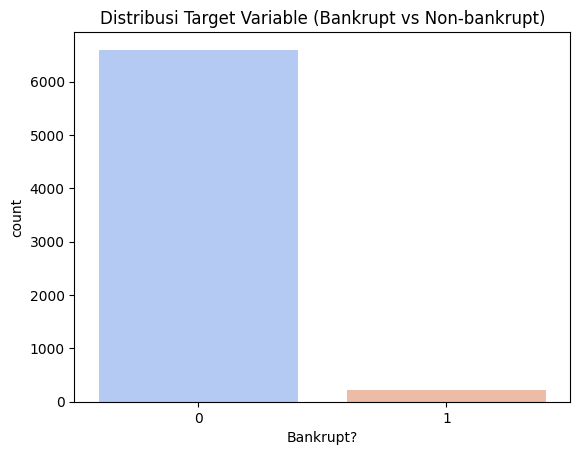

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [46]:
#Data understanding
print("Data Shape :",data.shape)
data.info()
missing = data.isnull().sum().sum()
print(f"Total missing values: {missing}")

sns.countplot(x='Bankrupt?', data=data, palette='coolwarm')
plt.title("Distribusi Target Variable (Bankrupt vs Non-bankrupt)")
plt.show()

data.describe()

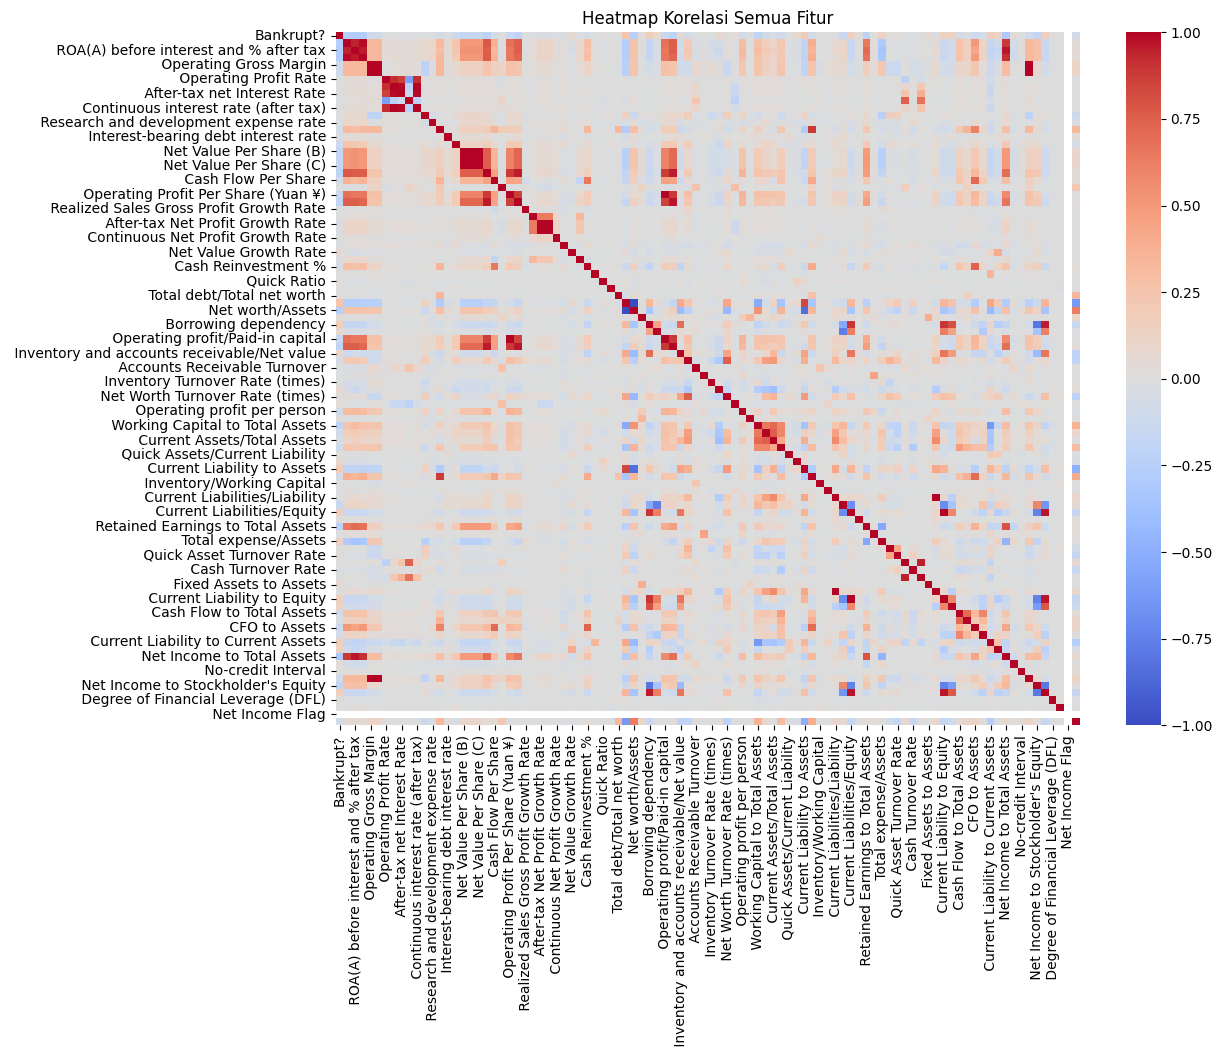

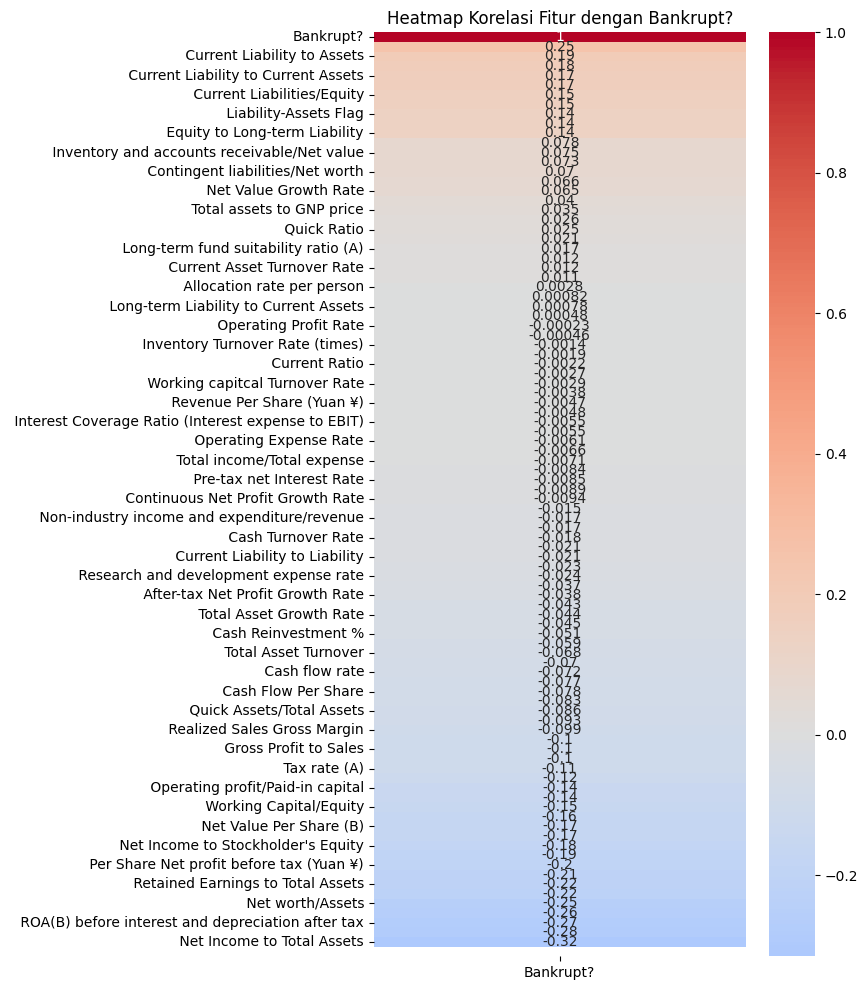

In [52]:
corr = data.corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Heatmap Korelasi Semua Fitur")
plt.show()

plt.figure(figsize=(6,12))
sns.heatmap(corr[['Bankrupt?']].sort_values(by='Bankrupt?', ascending=False), annot=True, cmap='coolwarm', center=0)
plt.title("Heatmap Korelasi Fitur dengan Bankrupt?")
plt.show()

###3. Data Preparation. Apakah data ini balance?
>Tidak, data ini sangat tidak balance dimana distribusinya didominasi oleh tidak bankrut atau "0".
Untuk penanganannya, menggunakan SMOTE

In [49]:
## ----------------------------------------------------
## 3. Data Preparation
## ----------------------------------------------------

# Tentukan X (Fitur) dan y (Target)
X = data.drop('Bankrupt?', axis=1)
y = data['Bankrupt?']

print(y.value_counts())

# 3A. Pemisahan Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nJumlah sampel Train Set: {len(X_train)}")
print(f"Jumlah sampel Test Set: {len(X_test)}")
print(f"Proporsi kelas di Train Set (0/1): {Counter(y_train)}")
print(f"Proporsi kelas di Test Set (0/1): {Counter(y_test)}")

# 3B. Feature Scaling (StandardScaler) [cite: 60]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"\nJumlah sampel Train Set setelah SMOTE: {len(X_train_res)}")
print(f"Proporsi kelas setelah SMOTE: {Counter(y_train_res)}")

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Jumlah sampel Train Set: 5455
Jumlah sampel Test Set: 1364
Proporsi kelas di Train Set (0/1): Counter({0: 5279, 1: 176})
Proporsi kelas di Test Set (0/1): Counter({0: 1320, 1: 44})

Jumlah sampel Train Set setelah SMOTE: 10558
Proporsi kelas setelah SMOTE: Counter({0: 5279, 1: 5279})


In [36]:
## ----------------------------------------------------
## 4. Modelling
## ----------------------------------------------------

# 4A. Fungsi Evaluasi Model
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    prec_0 = precision_score(y_test, y_pred, pos_label=0)
    prec_1 = precision_score(y_test, y_pred, pos_label=1)

    return {
        'Model': name,
        'Accuracy': acc,
        'F1-Score': f1,
        'Recall': recall,
        'Precision_0': prec_0,
        'Precision_1': prec_1
    }

# 4B. Model Base
classifiers = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'Gaussian Naive Bayes': GaussianNB()
}

# 4C. Evaluasi 11 Algoritma Base
results = []
trained_models = {}

for name, model in classifiers.items():
    print(f"Evaluating {name} ...")
    result = evaluate_model(model, X_train_res, y_train_res, X_test_scaled, y_test, name)
    results.append(result)
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\n--- HASIL PENGUJIAN AWAL 11 MODEL ---")
print(results_df)


# 4D. Definisi Model Tuned
xgb_tuned = XGBClassifier(
    n_estimators=1000, learning_rate=0.01, max_depth=5,
    min_child_weight=1, gamma=0.2, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=29,
    random_state=42, use_label_encoder=False, eval_metric='logloss'
)

lgb_tuned = LGBMClassifier(
    n_estimators=800, learning_rate=0.01, max_depth=-1,
    num_leaves=40, subsample=0.8, colsample_bytree=0.8,
    random_state=42
)

rf_tuned = RandomForestClassifier(
    n_estimators=500, max_depth=None,
    class_weight='balanced', random_state=42
)

gb_tuned = GradientBoostingClassifier(
    n_estimators=800, learning_rate=0.01,
    max_depth=3, random_state=42
)

et_tuned = ExtraTreesClassifier(
    n_estimators=700, max_depth=None,
    class_weight='balanced', random_state=42
)

# 4E. Kumpulkan Semua Model Tuned
tuned_models = {
    "XGBoost_Tuned": xgb_tuned,
    "LightGBM_Tuned": lgb_tuned,
    "Random Forest_Tuned": rf_tuned,
    "Gradient Boosting_Tuned": gb_tuned,
    "Extra Trees_Tuned": et_tuned
}

# 4F. Evaluasi Semua Model Tuned
final_results_data = []
for name, model in tuned_models.items():
    print(f"Training & evaluating {name} ...")
    result = evaluate_model(model, X_train_res, y_train_res, X_test_scaled, y_test, name)
    final_results_data.append(result)
    trained_models[name] = model

final_results_df = pd.DataFrame(final_results_data).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\n--- HASIL TUNING 5 MODEL TERBAIK ---")
print(final_results_df)


# 4G. Pilih Model Terbaik
best_model_name = final_results_df.iloc[0]['Model']
best_model = trained_models.get(best_model_name)

print(f"\n=== Model Terbaik Setelah Tuning: {best_model_name} ===")


Evaluating Random Forest ...
Evaluating Logistic Regression ...
Evaluating SVM ...
Evaluating Gradient Boosting ...
Evaluating XGBoost ...
Evaluating LightGBM ...
Evaluating AdaBoost ...
Evaluating K-Nearest Neighbors ...
Evaluating Decision Tree ...
Evaluating Extra Trees ...
Evaluating Gaussian Naive Bayes ...

--- HASIL PENGUJIAN AWAL 11 MODEL ---
                   Model  Accuracy  F1-Score    Recall  Precision_0  \
0               LightGBM  0.966276  0.520833  0.568182     0.985518   
1          Random Forest  0.959677  0.485981  0.590909     0.986164   
2                XGBoost  0.963343  0.479167  0.522727     0.983994   
3            Extra Trees  0.959677  0.432990  0.477273     0.982456   
4      Gradient Boosting  0.938416  0.416667  0.681818     0.988924   
5          Decision Tree  0.940616  0.330579  0.454545     0.981352   
6    Logistic Regression  0.884164  0.300885  0.772727     0.991540   
7               AdaBoost  0.896628  0.298507  0.681818     0.988401   
8       


=== Evaluasi Model Terbaik: LightGBM_Tuned ===


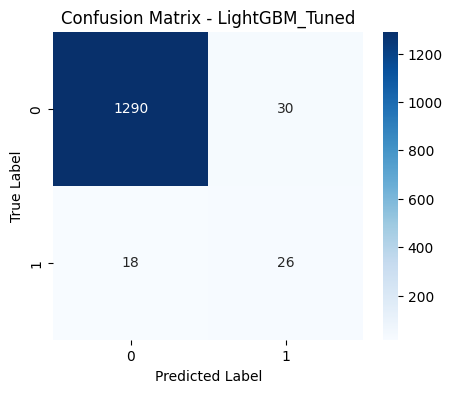


=== Performance Metrics (LightGBM_Tuned) ===
Accuracy  : 0.9648
F1-Score  : 0.5200
Recall    : 0.5909
Precision : 0.4643

--- Detailed Classification Report ---

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1320
           1       0.46      0.59      0.52        44

    accuracy                           0.96      1364
   macro avg       0.73      0.78      0.75      1364
weighted avg       0.97      0.96      0.97      1364


AUC Score untuk model LightGBM_Tuned: 0.9507


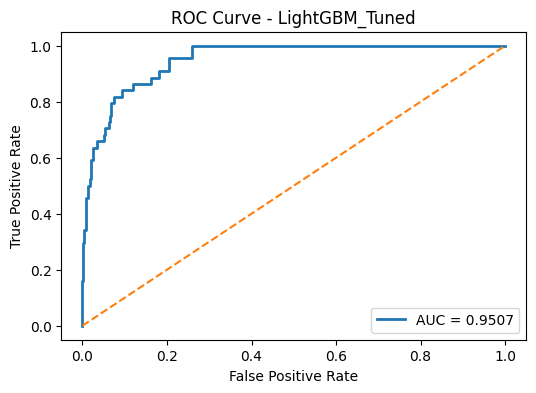

In [53]:
## ----------------------------------------------------
## 5. Evaluasi Model Terbaik
## ----------------------------------------------------

print(f"\n=== Evaluasi Model Terbaik: {best_model_name} ===")

# 5A. Prediksi menggunakan model terbaik
y_pred_best = best_model.predict(X_test_scaled)

# 5B. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 5C. Classification Metrics
accuracy = accuracy_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)

print(f"\n=== Performance Metrics ({best_model_name}) ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"Precision : {precision:.4f}")

print("\n--- Detailed Classification Report ---\n")
print(classification_report(y_test, y_pred_best))

# 5D. ROC Curve + Perhitungan AUC
if hasattr(best_model, "predict_proba"):
    # Probabilitas kelas 1
    y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

    # Hitung FPR, TPR, dan AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
    roc_auc = auc(fpr, tpr)

    # Cetak nilai AUC secara eksplisit
    print(f"\nAUC Score untuk model {best_model_name}: {roc_auc:.4f}")

    # Plot ROC Curve
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(f"ROC Curve - {best_model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

else:
    print(f"\n{best_model_name} tidak mendukung predict_proba(), ROC Curve & AUC tidak dapat dihitung.")




Top 5 Variabel Paling Berpengaruh Terhadap Kebangkrutan:

Inventory Turnover Rate (times)          1049
Research and development expense rate    1020
Total Asset Growth Rate                   937
Current Asset Turnover Rate               868
Interest-bearing debt interest rate       867
dtype: int32


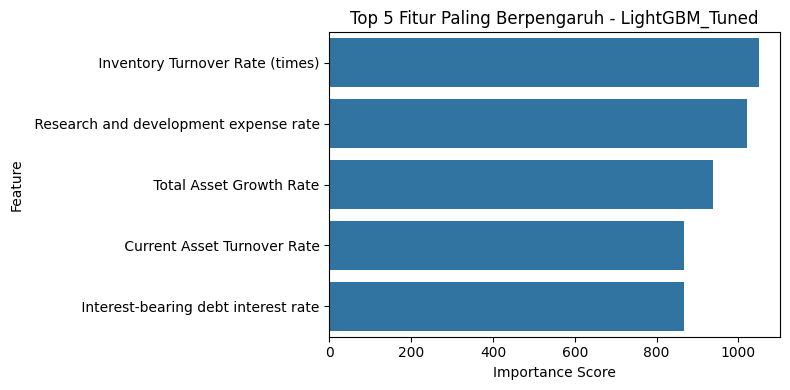

In [38]:
## ----------------------------------------------------
## 6. Top 5 Feature Paling Berpengaruh
## ----------------------------------------------------

# Cek apakah model punya "feature_importances_"
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)

# Jika tidak, cek apakah punya "coef_" (contoh: Logistic Regression)
elif hasattr(best_model, "coef_"):
    # Ambil koefisien dan pakai nilai absolut
    importances = pd.Series(abs(best_model.coef_[0]), index=X.columns)

# Jika tidak ada keduanya → tidak bisa hitung importance
else:
    print(f"\nModel '{best_model_name}' tidak mendukung perhitungan feature importance.")
    print("Coba gunakan model berbasis pohon seperti RandomForest atau XGBoost.")
    importances = None

# Jika importance tersedia → proses top 5
if importances is not None:
    # Ambil 5 fitur teratas
    top5_features = importances.sort_values(ascending=False).head(5)

    print("\nTop 5 Variabel Paling Berpengaruh Terhadap Kebangkrutan:\n")
    print(top5_features)

    # Visualisasi
    plt.figure(figsize=(8,4))
    sns.barplot(x=top5_features.values, y=top5_features.index)
    plt.title(f"Top 5 Fitur Paling Berpengaruh - {best_model_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
